## Regression-Based Harmonisation

As a simple baseline, we can use regression to remove site-related mean shifts from the data.

For each feature, we fit a model like:

$$
y = \beta_0 + \beta_1 \text{Age} + \beta_2 \text{Timepoint} + \gamma \text{Site} + \epsilon
$$

Here:

- the **site term** captures additive scanner/batch effects,
- age and timepoint are kept as biological covariates,
- the residual part represents variation not explained by site.

# Regression-Based Harmonisation Workflow

In this section, we will use a simple regression-based approach to reduce site-related variability in the simulated data.

The goal is to demonstrate:
- what regression-based harmonisation can correct,
- and why more advanced methods such as ComBat-like approaches may still be needed.

---

## Steps

### 1. Simulate longitudinal multi-site data

We first generate synthetic imaging data containing:

- repeated measurements,
- biological variation,
- covariate effects (e.g., Age),
- additive site effects,
- and multiplicative site effects.

This creates a realistic harmonisation scenario where scanner/site effects are intentionally introduced.

---

### 2. Visualize site-related effects

Before harmonisation, we inspect the distributions across sites using boxplots.

This helps identify:
- additive effects → shifts in mean values,
- multiplicative effects → differences in spread/variance.

---

### 3. Apply regression-based harmonisation

We fit regression models that include:
- biological covariates,
- timepoint information,
- and site/scanner terms.

The estimated site effects are then removed from the data.

This approach primarily targets additive batch effects.

---

### 4. Visualize the harmonized data

We compare the distributions before and after correction to assess:
- reduction in site-related mean shifts,
- preservation of biological variability,
- and any remaining variance differences.

---

### 5. Evaluate remaining batch effects

Finally, we re-run:
- additive effect tests,
- multiplicative effect tests,
- and reliability metrics.

This allows us to evaluate how much scanner/site variability remains after harmonisation.

---

## Key Concept

Regression-based harmonisation is useful for correcting systematic mean shifts across sites.

However, if scanners also differ in variability or scale, regression alone may not be sufficient.

This motivates the use of ComBat-like harmonisation methods, which aim to model and remove both:
- additive effects,
- and multiplicative effects.

   Subject Timepoint    Site   Age  Feature_1  Feature_2  Feature_3  Feature_4
0        1       TP0  Site_B  78.0     2380.5      311.5     2362.7     2381.3
1        1       TP1  Site_A  78.0     1553.1     1432.5     2487.1     2139.8
2        1       TP2  Site_A  78.0     1533.2     1459.7     2497.8     2631.7
3        2       TP0  Site_A  60.1     1660.3     1607.4     2150.7     2665.7
4        2       TP1  Site_B  60.1     2484.2     2538.6     1978.2     2424.2
5        2       TP2  Site_A  60.1     1700.5     1658.8     2159.9     2834.3
6        3       TP0  Site_A  60.8     1634.4     1476.3     2191.8     2028.4
7        3       TP1  Site_A  60.8     1626.8     1512.9     2169.2     2479.2
8        3       TP2  Site_A  60.8     1634.4     1512.3     2220.3     2382.6
9        4       TP0  Site_A  56.4     1629.5     1742.7     2199.9     2286.1


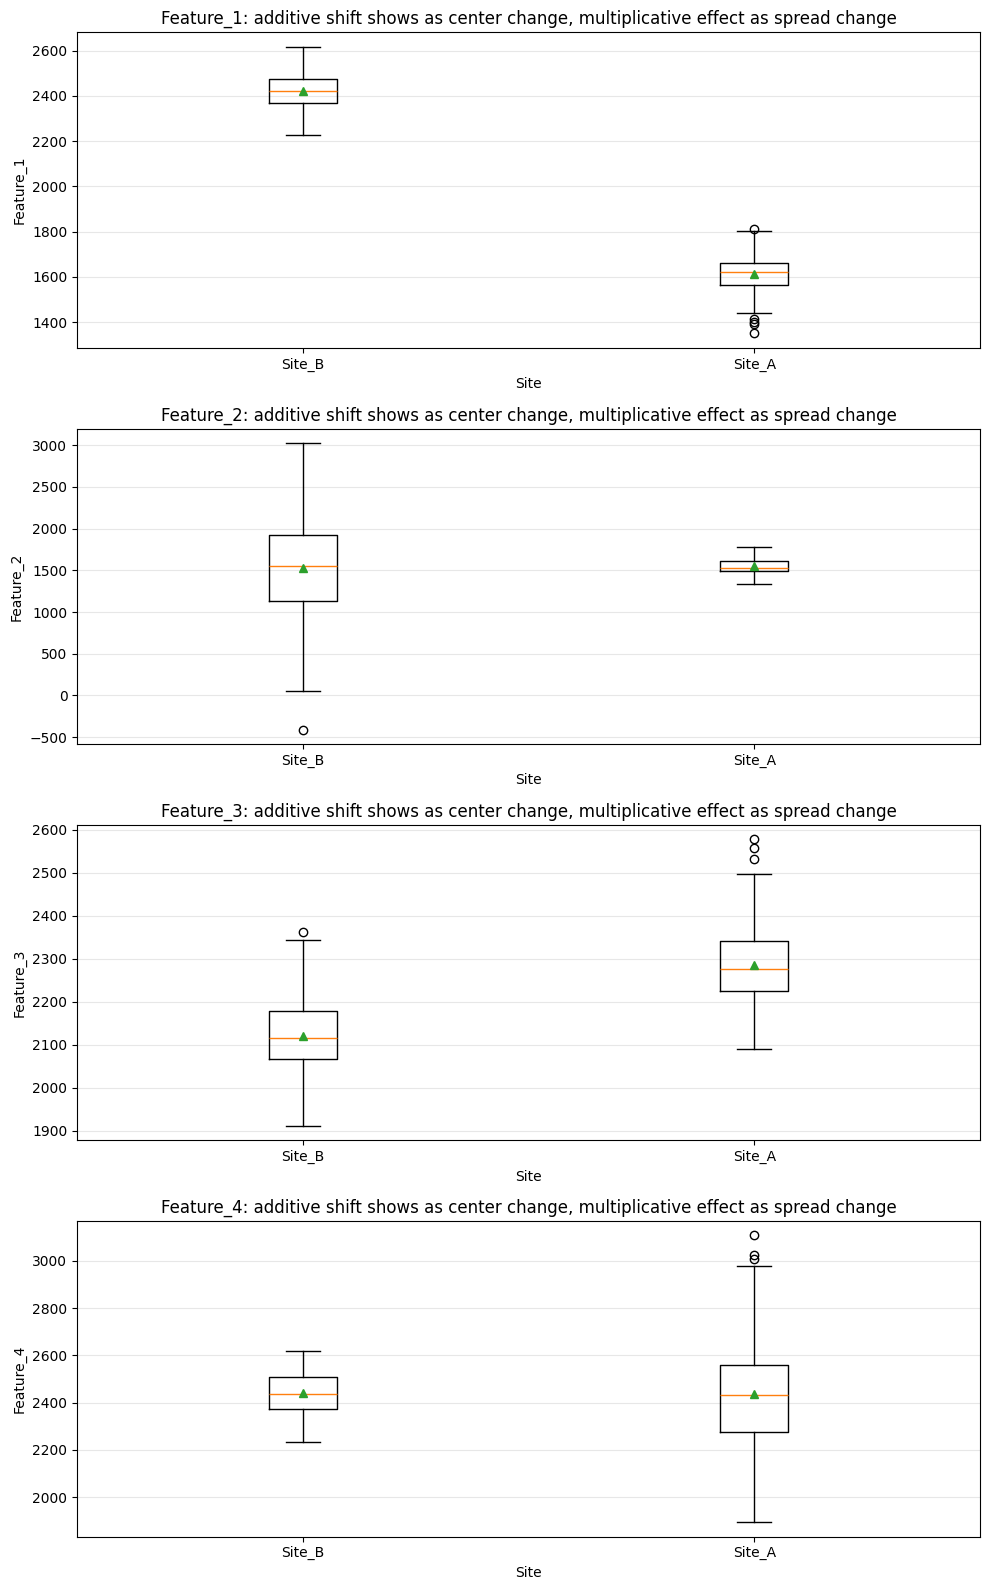

In [ ]:
from block2_utils.HarmonisationEvaluation_functions import (
    simulate_longitudinal_batch_data_mixed,
)
from block2_utils.HarmonisationEvaluation_plots import (
    plot_additive_multiplicative_effects,
)

# Simulate 100 subjects, 3 timepoints, 2 sites, 4 features
n_subjects=100
n_timepoints=3
n_sites=2
n_features=4
additive_shift = {"Site_B": {"Feature_1": 800, "Feature_3": -150}}
multiplicative_scale = {"Site_B": {"Feature_2": 30.0}, "Site_A": {"Feature_4": 10}}

df = simulate_longitudinal_batch_data_mixed(
    n_subjects=n_subjects,
    n_timepoints=n_timepoints,
    n_sites=n_sites,
    n_features=n_features,
    additive_shift=additive_shift,
    multiplicative_scale=multiplicative_scale,
    seed=1,
)

print(df.head(10))
feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

# Visualise additive and multiplicative effects
plot_additive_multiplicative_effects(df, feature_cols=feature_cols, batch_col="Site")


Model Summary
     Feature                                   Formula    Site_pvalue  \
0  Feature_1  Feature_1 ~ Age + C(Timepoint) + C(Site)  1.632206e-212   
1  Feature_2  Feature_2 ~ Age + C(Timepoint) + C(Site)   7.166434e-01   
2  Feature_3  Feature_3 ~ Age + C(Timepoint) + C(Site)   6.696867e-42   
3  Feature_4  Feature_4 ~ Age + C(Timepoint) + C(Site)   7.744116e-01   

         R2  
0  0.962826  
1  0.027210  
2  0.477192  
3  0.012216  
   Subject Timepoint    Site   Age  Feature_1  Feature_2  Feature_3  \
0        1       TP0  Site_B  78.0     2380.5      311.5     2362.7   
1        1       TP1  Site_A  78.0     1553.1     1432.5     2487.1   
2        1       TP2  Site_A  78.0     1533.2     1459.7     2497.8   
3        2       TP0  Site_A  60.1     1660.3     1607.4     2150.7   
4        2       TP1  Site_B  60.1     2484.2     2538.6     1978.2   

   Feature_4  Feature_1_harm  Feature_2_harm  Feature_3_harm  Feature_4_harm  
0     2381.3     1897.147971      322.295887

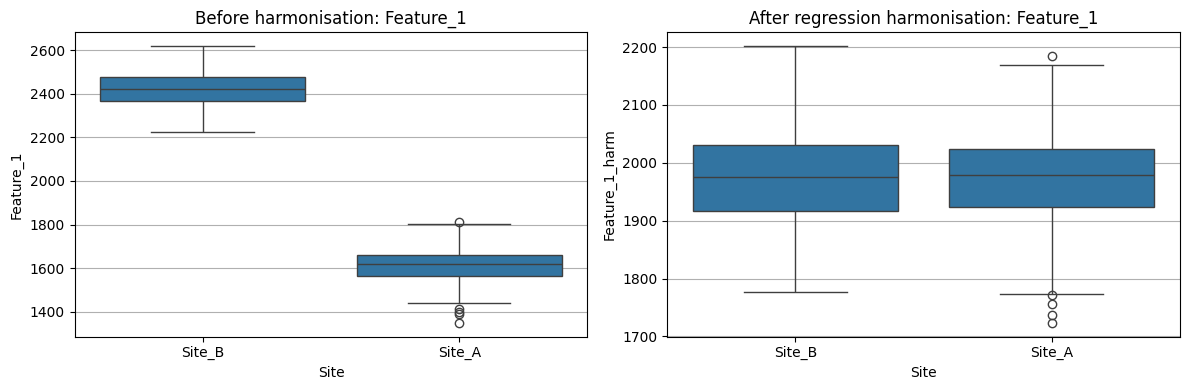

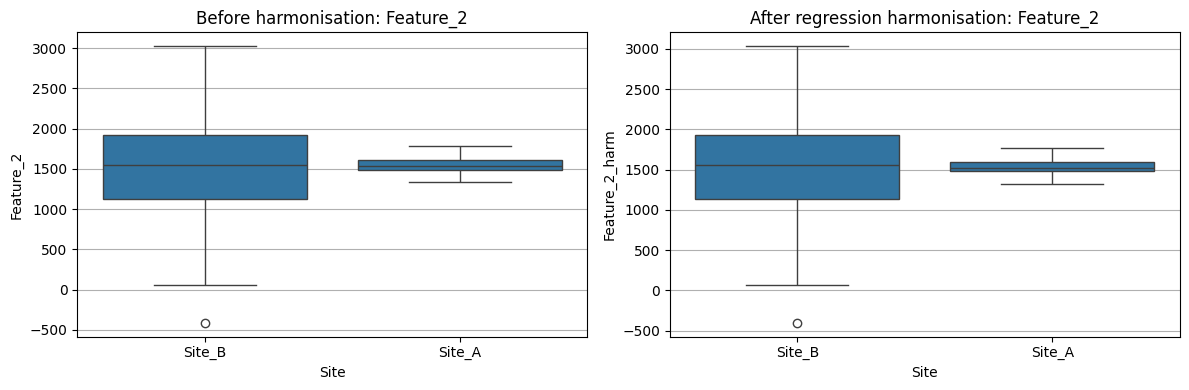

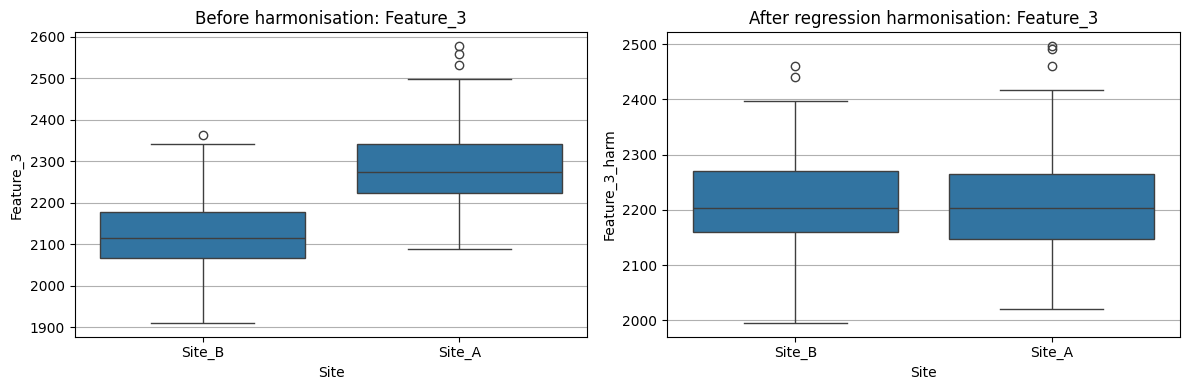

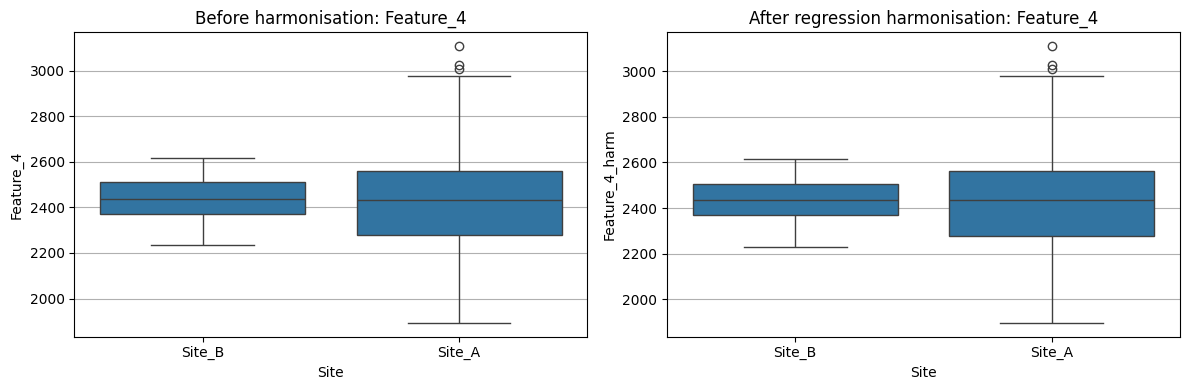

In [3]:
from block2_utils.HarmonisationEvaluation_functions import regression_harmonize_site
from block2_utils.HarmonisationEvaluation_plots import plot_before_after_by_site


feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

df_harm, model_summary = regression_harmonize_site(
    df, feature_cols=feature_cols, site_col="Site", covariates=("Age", "Timepoint")
)
print("=="*40)
print("Model Summary")
print("=="*40)
print(model_summary)
print("=="*40)
print(df_harm.head())
print("=="*40)
plot_before_after_by_site(df_harm, feature_cols)

## Interpreting the Regression Output

The regression summary table provides feature-wise information about the relationship between the imaging measurements and site effects.

Typical columns include:

- **Feature**  
  The imaging feature/region being analysed.

- **Formula**  
  The regression model used for harmonisation.

- **Site_pvalue**  
  Statistical significance of the site/scanner term.

  - small p-values suggest strong site-related mean shifts
  - non-significant values suggest weaker additive batch effects

- **R2**  
  Proportion of variance explained by the regression model.

Higher values indicate that the model explains a larger portion of variability in the feature.

### Expected observations

Before harmonisation:
- regions with simulated additive effects should often show significant site terms.

After regression-based harmonisation:
- site-related mean differences should reduce,
- and visual separation across sites should become smaller.

However, variance differences may still remain for regions with multiplicative batch effects.

## Exercise: Regression-Based Harmonisation

In this exercise, simulate longitudinal multi-site imaging data containing:

- additive batch effects,
- multiplicative batch effects,
- and biological covariates (e.g., Age).

Then:

1. Visualize the site-related effects before harmonisation.
2. Apply regression-based harmonisation.
3. Visualize the harmonized data.
4. Re-run additive and multiplicative effect tests.

### Questions

- Which site effects were reduced after regression harmonisation?
- Which effects still remained?
- Why might regression be insufficient for multiplicative batch effects?
- How could ComBat-like methods improve upon this?

### Solution

You can check the solution code in [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block02).

### Before applying site regression

Prior to harmonisation, the additive batch effect analysis identified statistically significant site-related shifts in mean feature values for `Feature_1` and `Feature_3`, indicating the presence of additive scanner/site effects.

In contrast, the multiplicative batch effect analysis using the Fligner test demonstrated significant site-related differences in variance for `Feature_2` and `Feature_4`, consistent with multiplicative batch effects affecting measurement variability across sites.

These findings indicate that the simulated dataset contains both additive and multiplicative sources of scanner/site bias.

### After applying site harmonisation

Following regression-based site harmonisation, the additive batch effect for `Feature_1` was no longer statistically significant (`p > 0.05`), suggesting that the regression approach successfully reduced the corresponding site-related mean shift.

However, residual additive effects remained evident for `Feature_3`, indicating incomplete removal of site-related bias for this feature.

Importantly, the harmonisation approach did not substantially reduce the multiplicative batch effects observed for `Feature_2` and `Feature_4`, as the variance-related site differences remained statistically significant before and after harmonisation.

Overall, these results illustrate that standard regression-based harmonisation approaches are generally effective for correcting additive mean shifts, but may be insufficient for addressing multiplicative effects that primarily influence feature variance.


Before Regression Additive effect: 
     Feature     TestStat  df   p-value method
0  Feature_1  1227.929842   1  0.000000   Wald
1  Feature_3   388.934047   1  0.000000   Wald
2  Feature_4     0.140928   1  0.707360   Wald
3  Feature_2     0.072801   1  0.787301   Wald
Before Regression Multiplicative effect: 
     Feature      ChiSq  DF       p-value   method
0  Feature_2  93.614470   1  3.833746e-22  Fligner
1  Feature_4  28.095495   1  1.154743e-07  Fligner
2  Feature_3   0.018010   1  8.932425e-01  Fligner
3  Feature_1   0.013899   1  9.061513e-01  Fligner
After Regression Additive effect: 
          Feature   TestStat  df   p-value method
0  Feature_3_harm  16.603393   1  0.000046   Wald
1  Feature_1_harm   5.043225   1  0.024722   Wald
2  Feature_4_harm   0.227936   1  0.633059   Wald
3  Feature_2_harm   0.049771   1  0.823463   Wald
After Regression Multiplicative effect: 
          Feature      ChiSq  DF       p-value   method
0  Feature_2_harm  93.910438   1  3.301286e-22  Fl

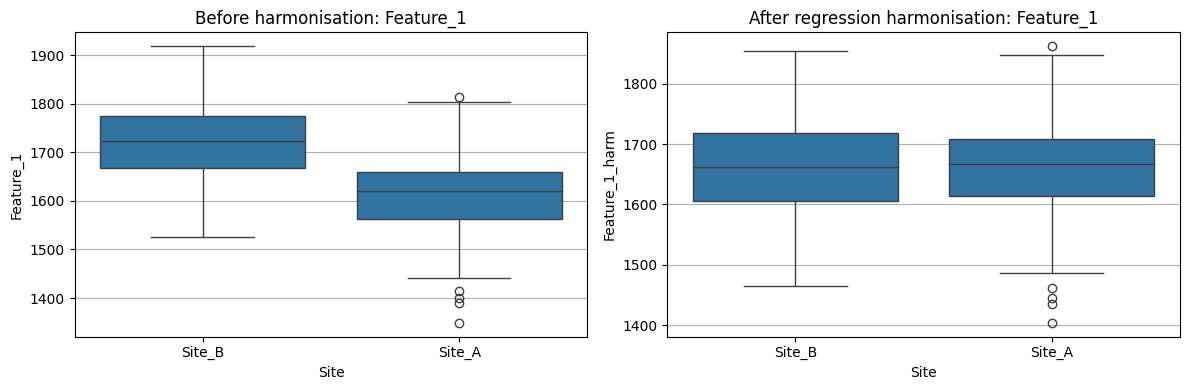

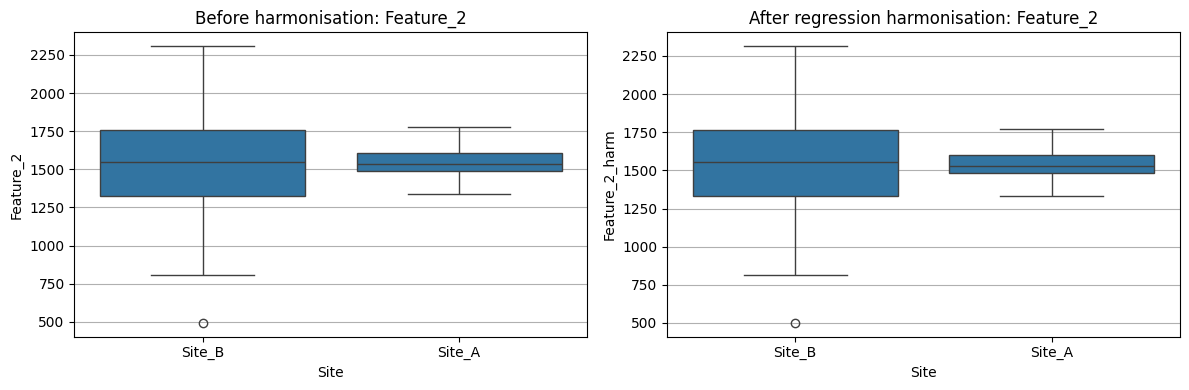

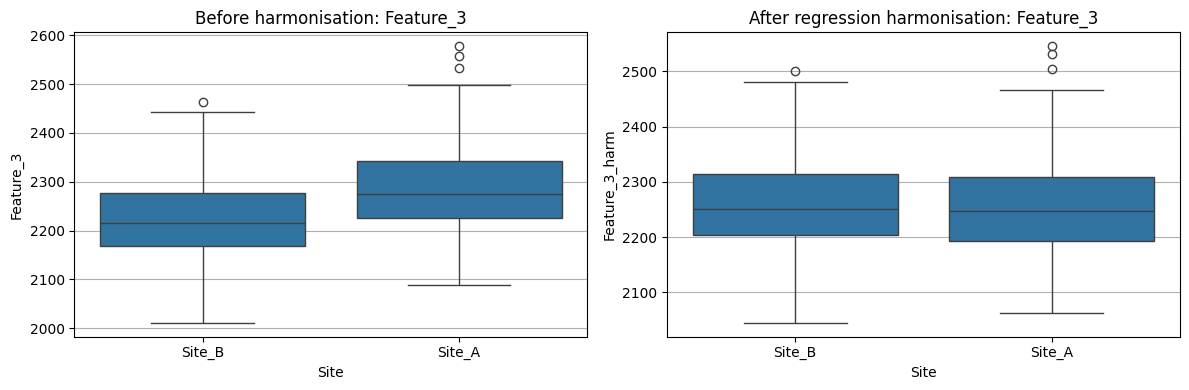

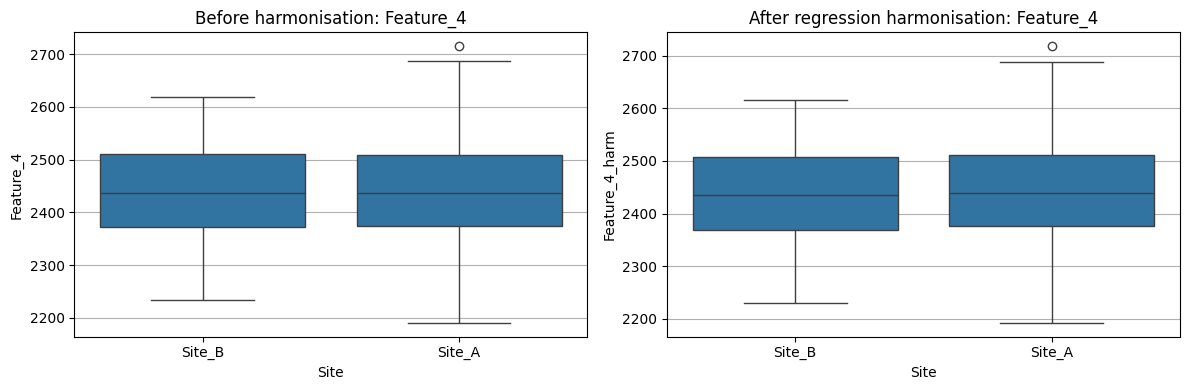

In [4]:
# Exercise solution:

import warnings
warnings.filterwarnings("ignore")

from block2_utils.HarmonisationEvaluation_functions import simulate_longitudinal_batch_data_mixed
#from block2_utils.HarmonisationEvaluation_plots import plot_additive_multiplicative_effects
from block2_utils.HarmonisationEvaluation_functions import AdditiveEffect_long
from block2_utils.HarmonisationEvaluation_functions import MultiplicativeEffect_long
from block2_utils.HarmonisationEvaluation_functions import regression_harmonize_site
from block2_utils.HarmonisationEvaluation_plots import plot_before_after_by_site

# Let's simulate some data: 100 subjects, 3 timepoints, 2 sites, features from 4 brain regions
n_subjects=100
n_timepoints=3
n_sites=2
n_features=4
additive_shift = {"Site_B": {"Feature_1": 100, "Feature_3": -50}}
multiplicative_scale = {"Site_B": {"Feature_2": 15.0}, "Site_A": {"Feature_4": 2.7}}

df = simulate_longitudinal_batch_data_mixed(
    n_subjects=n_subjects,
    n_timepoints=n_timepoints,
    n_sites=n_sites,
    n_features=n_features,
    additive_shift=additive_shift,
    multiplicative_scale=multiplicative_scale,
    seed=1,
)

#print(df.head(10))
feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

# Let's visualise additive and multiplicative effects
#plot_additive_multiplicative_effects(df, feature_cols=feature_cols, batch_col="Site")

feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

# Let's estimate additive and multiplicative batch effects
before_additive_results = AdditiveEffect_long(
    data=df,
    idp_names=feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar="Timepoint",
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print(f"Before Regression Additive effect: \n{before_additive_results}")

before_multiplicative_results = MultiplicativeEffect_long(
    data=df,
    idp_names=feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar="Timepoint",
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print(f"Before Regression Multiplicative effect: \n{before_multiplicative_results}")

# Let's regress the site effect
feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

df_harm, model_summary = regression_harmonize_site(
    df, feature_cols=feature_cols, site_col="Site", covariates=("Age", "Timepoint")
)
#print("=="*40)
#print("Model Summary")
#print("=="*40)
#print(model_summary)
#print("=="*40)
#print(df_harm.head())
#print("=="*40)

# Let's estimate additive and multiplicative batch effects
feature_cols = [f"Feature_{i}_harm" for i in range(1, n_features + 1)]

after_additive_results = AdditiveEffect_long(
    data=df_harm,
    idp_names=feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar="Timepoint",
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print(f"After Regression Additive effect: \n{after_additive_results}")

after_multiplicative_results= MultiplicativeEffect_long(
    data=df_harm,
    idp_names=feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar="Timepoint",
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print(f"After Regression Multiplicative effect: \n{after_multiplicative_results}")

# plot before and after regression
feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]
plot_before_after_by_site(df_harm, feature_cols)
